In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

aapl = pd.read_csv(INTERIM_DIR / "AAPL_clean.csv", parse_dates=["Date"])
spx = pd.read_csv(INTERIM_DIR / "GSPC_clean.csv", parse_dates=["Date"])

aapl = aapl.set_index("Date")
spx = spx.set_index("Date")

print(aapl.shape, spx.shape)
aapl.head()

(2516, 7) (2516, 7)


,Ticker,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.192600,212818400
2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.511059,257142000
2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.513277,263188400
2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,23.842979,160423600
2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.759077,237458000


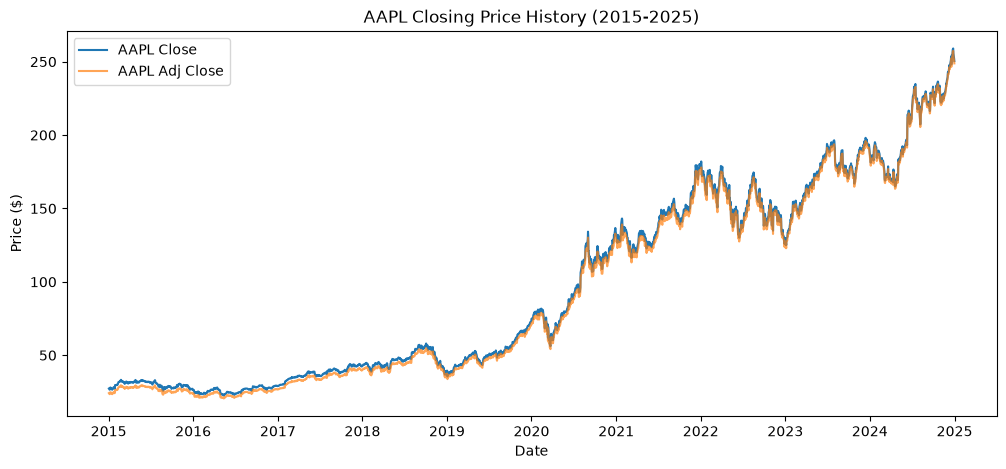

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(aapl.index, aapl["Close"], label="AAPL Close")
ax.plot(aapl.index, aapl["Adj Close"], label="AAPL Adj Close", alpha=0.7)
ax.set_title("AAPL Closing Price History (2015-2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()

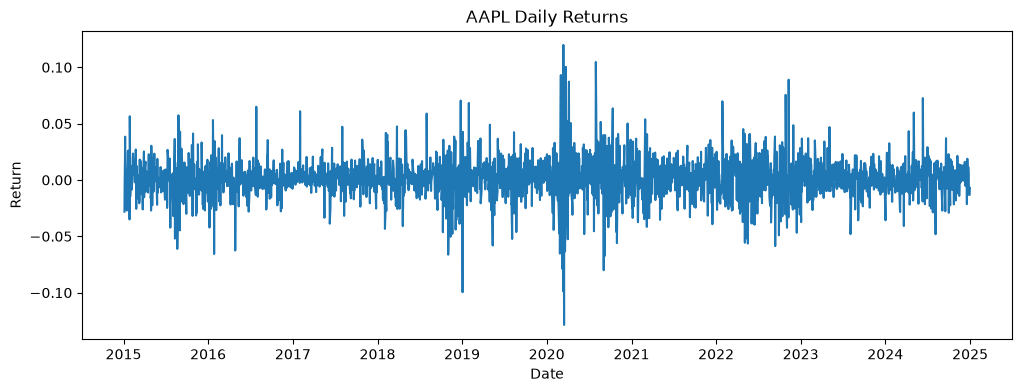

count    2515.000000
mean        0.001088
std         0.017929
min        -0.128647
25%        -0.007326
50%         0.001001
75%         0.010142
max         0.119808
Name: daily_return, dtype: float64

In [3]:
aapl["daily_return"] = aapl["Adj Close"].pct_change()
aapl["log_return"] = np.log(aapl["Adj Close"] / aapl["Adj Close"].shift(1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aapl.index, aapl["daily_return"])
ax.set_title("AAPL Daily Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
plt.show()

aapl["daily_return"].describe()

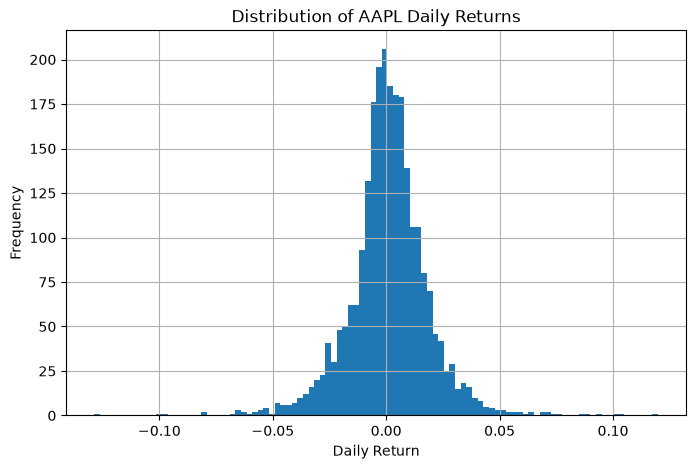

Skew: -0.003056920709387708
Kurtosis: 5.313263505678458


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
aapl["daily_return"].dropna().hist(bins=100, ax=ax)
ax.set_title("Distribution of AAPL Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.show()

print("Skew:", aapl["daily_return"].skew())
print("Kurtosis:", aapl["daily_return"].kurtosis())

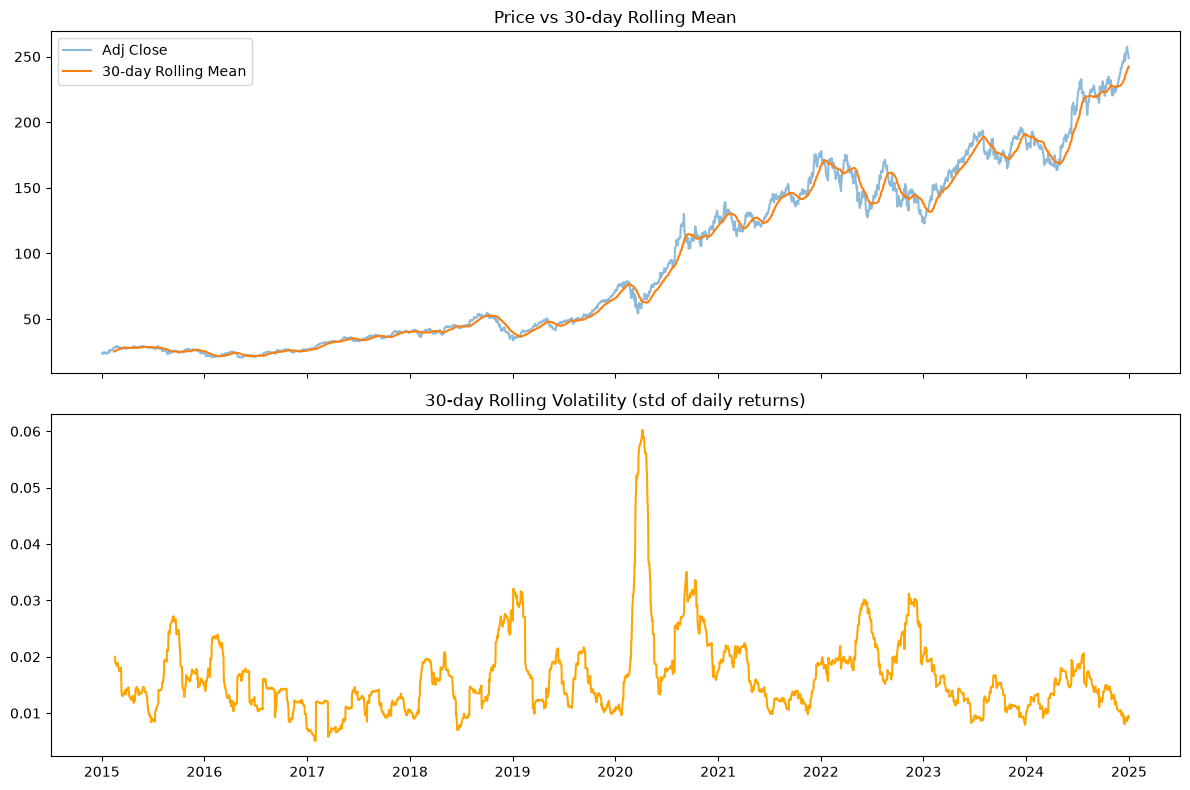

In [5]:
aapl["rolling_mean_30"] = aapl["Adj Close"].rolling(30).mean()
aapl["rolling_vol_30"] = aapl["daily_return"].rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(aapl.index, aapl["Adj Close"], label="Adj Close", alpha=0.5)
axes[0].plot(aapl.index, aapl["rolling_mean_30"], label="30-day Rolling Mean")
axes[0].legend()
axes[0].set_title("Price vs 30-day Rolling Mean")

axes[1].plot(aapl.index, aapl["rolling_vol_30"], color="orange")
axes[1].set_title("30-day Rolling Volatility (std of daily returns)")
plt.tight_layout()
plt.show()

Correlation between AAPL and S&P 500 daily returns: 0.747


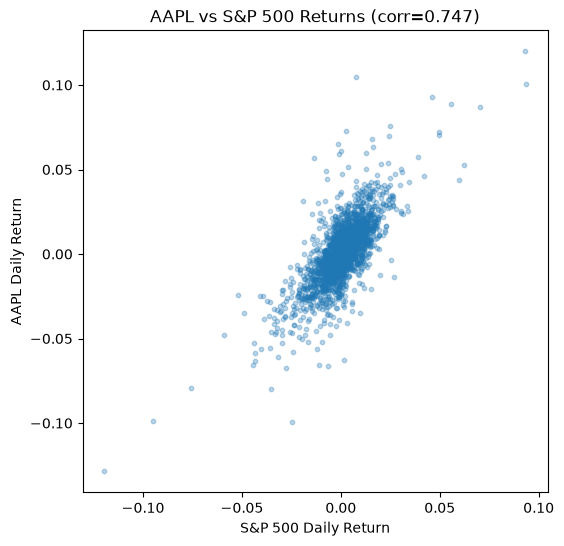

In [6]:
spx["daily_return"] = spx["Adj Close"].pct_change()

combined = pd.DataFrame({
    "AAPL": aapl["daily_return"],
    "SPX": spx["daily_return"],
}).dropna()

correlation = combined["AAPL"].corr(combined["SPX"])
print(f"Correlation between AAPL and S&P 500 daily returns: {correlation:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(combined["SPX"], combined["AAPL"], alpha=0.3, s=10)
ax.set_xlabel("S&P 500 Daily Return")
ax.set_ylabel("AAPL Daily Return")
ax.set_title(f"AAPL vs S&P 500 Returns (corr={correlation:.3f})")
plt.show()

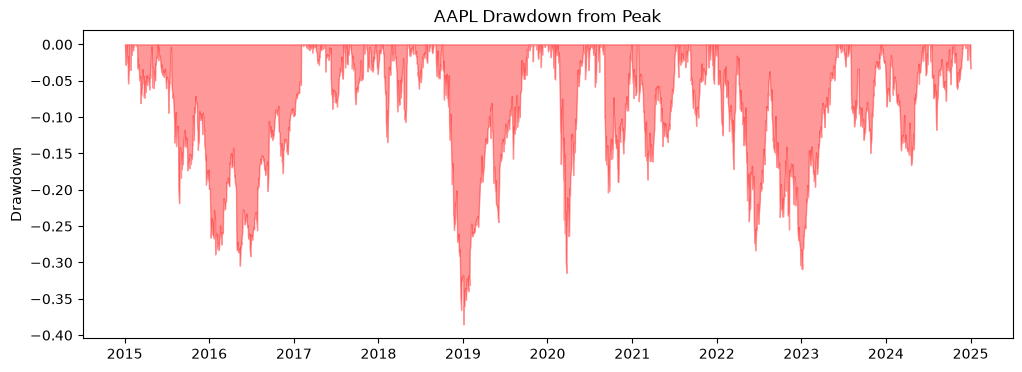

Maximum drawdown: -38.52%


In [7]:
cumulative = (1 + aapl["daily_return"].fillna(0)).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(aapl.index, drawdown, 0, color="red", alpha=0.4)
ax.set_title("AAPL Drawdown from Peak")
ax.set_ylabel("Drawdown")
plt.show()

print(f"Maximum drawdown: {drawdown.min():.2%}")

In [8]:
print("Missing values per column:")
print(aapl.isna().sum())

print("\nExtreme return days (top 5 absolute moves):")
print(aapl["daily_return"].abs().sort_values(ascending=False).head(5))

Missing values per column:
Ticker              0
Open                0
High                0
Low                 0
Close               0
Adj Close           0
Volume              0
daily_return        1
log_return          1
rolling_mean_30    29
rolling_vol_30     30
dtype: int64

Extreme return days (top 5 absolute moves):
Date
2020-03-16    0.128647
2020-03-13    0.119808
2020-07-31    0.104689
2020-03-24    0.100325
2019-01-03    0.099608
Name: daily_return, dtype: float64


## Stationarity Considerations

Raw closing prices are non-stationary (they trend over time, mean and
variance change) - most classical statistical tests and many ML models
assume stationarity. Daily returns are much closer to stationary
(roughly constant mean/variance over time), though volatility
clustering shows the *variance* isn't perfectly constant either
(this is called heteroscedasticity).

This is why the project predicts **returns or direction**, not raw
price levels - it's both more statistically valid and more aligned
with how trading decisions are actually made.